## 1. Data Processing

In [ ]:
#https://slundberg.github.io/shap/notebooks/NHANES%20I%20Survival%20Model.html

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
'''Load the data'''
icu_data = pd.read_csv('./df.csv')
icu_data.set_index('PtID', inplace = True)
icu_data.head()

,DocID,DeltaSOFA,PatientAge,AdmissionType,Department,Comorbidity,APACHEII,SOFA,PatientSex,DischargeStatus,...,SciKno,OverallSc,Worksite,Leadership,PhysicianRank,PhysicianAveSc,PhysicianEval,PhysicianSex,Training,PhysicianAge
PtID,,,,,,,,,,,,,,,,,,,,,
101008,doc-01,6,ge60,no_op,medical,1,24,7,M,A,...,4,5.0,2+,leader_x,senior,4.033301,2,F,anesthesia,50+
101127,doc-01,0,ge60,no_op,medical,1,27,9,M,A,...,4,5.0,2+,leader_x,senior,4.033301,2,F,anesthesia,50+
104350,doc-01,3,lt60,no_op,medical,1,16,4,M,D,...,4,5.0,2+,leader_x,senior,4.033301,2,F,anesthesia,50+
101033,doc-01,2,ge60,no_op,surgical,1,22,6,F,D,...,4,5.0,2+,leader_x,senior,4.033301,2,F,anesthesia,50+
101036,doc-01,3,lt60,no_op,surgical,1,21,7,M,D,...,4,5.0,2+,leader_x,senior,4.033301,2,F,anesthesia,50+


In [ ]:
print(icu_data.shape)
icu_data.info()

(2113, 33)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2113 entries, 101008 to 404278
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DocID            2113 non-null   object 
 1   DeltaSOFA        2113 non-null   int64  
 2   PatientAge       2113 non-null   object 
 3   AdmissionType    2113 non-null   object 
 4   Department       2113 non-null   object 
 5   Comorbidity      2113 non-null   int64  
 6   APACHEII         2113 non-null   int64  
 7   SOFA             2113 non-null   int64  
 8   PatientSex       2113 non-null   object 
 9   DischargeStatus  2113 non-null   object 
 10  LengthOfStay     2113 non-null   int64  
 11  Diagnosis        2113 non-null   object 
 12  MedicalFac       2113 non-null   float64
 13  ProfesFac1       2113 non-null   float64
 14  ProfesFac2       2113 non-null   float64
 15  CommuFac1        2113 non-null   float64
 16  CommuFac2        2113 non-null   float64
 

In [ ]:
'''
data cleaning:
    handle text and categorial attributes
'''
# I think one-hot encoding is probably better, but it's hard to interpret the variable importance, etc.
# Label Encoder might lead to the algorithm placing more importance on larger number, say 5 for {1, 2, 3, 4, 5}
# I think facotr() in r is similiar to one-hot encoding

idx = icu_data.select_dtypes(include = "object").columns
idx = idx.delete(0)
le = LabelEncoder()
icu_data[idx] = icu_data[idx].apply(le.fit_transform)

icu_data.head()

,DocID,DeltaSOFA,PatientAge,AdmissionType,Department,Comorbidity,APACHEII,SOFA,PatientSex,DischargeStatus,...,SciKno,OverallSc,Worksite,Leadership,PhysicianRank,PhysicianAveSc,PhysicianEval,PhysicianSex,Training,PhysicianAge
PtID,,,,,,,,,,,,,,,,,,,,,
101008,doc-01,6,0,1,0,1,24,7,1,0,...,4,5.0,1,1,1,4.033301,2,0,0,0
101127,doc-01,0,0,1,0,1,27,9,1,0,...,4,5.0,1,1,1,4.033301,2,0,0,0
104350,doc-01,3,1,1,0,1,16,4,1,1,...,4,5.0,1,1,1,4.033301,2,0,0,0
101033,doc-01,2,0,1,2,1,22,6,0,1,...,4,5.0,1,1,1,4.033301,2,0,0,0
101036,doc-01,3,1,1,2,1,21,7,1,1,...,4,5.0,1,1,1,4.033301,2,0,0,0


In [ ]:
icu_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2113 entries, 101008 to 404278
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DocID            2113 non-null   object 
 1   DeltaSOFA        2113 non-null   int64  
 2   PatientAge       2113 non-null   int64  
 3   AdmissionType    2113 non-null   int64  
 4   Department       2113 non-null   int64  
 5   Comorbidity      2113 non-null   int64  
 6   APACHEII         2113 non-null   int64  
 7   SOFA             2113 non-null   int64  
 8   PatientSex       2113 non-null   int64  
 9   DischargeStatus  2113 non-null   int64  
 10  LengthOfStay     2113 non-null   int64  
 11  Diagnosis        2113 non-null   int64  
 12  MedicalFac       2113 non-null   float64
 13  ProfesFac1       2113 non-null   float64
 14  ProfesFac2       2113 non-null   float64
 15  CommuFac1        2113 non-null   float64
 16  CommuFac2        2113 non-null   float64
 17  CommuFa

In [ ]:
'''Responses'''
# When DischargeStatus = "Alive", we observed the true ICU Length of Stay;
# When DischargeStatus = "Dead", we observed the censored ICU Length of Stay;
# XGBoost want the cenosed survival time coded as negative.
LengthOfStay = icu_data[['LengthOfStay']].copy()
DischargeStatus = icu_data[['DischargeStatus']].copy()
DischargeStatus.loc[DischargeStatus['DischargeStatus'] == 1, 'DischargeStatus'] = -1
DischargeStatus.loc[DischargeStatus['DischargeStatus'] == 0, 'DischargeStatus'] = 1
y = LengthOfStay * DischargeStatus.to_numpy()
y.head()

,LengthOfStay
PtID,
101008,36
101127,3
104350,-11
101033,-1
101036,-3


In [ ]:
'''covariates'''
idx = icu_data.columns
idx = idx.delete([idx.get_loc('DocID'), idx.get_loc('DischargeStatus'), idx.get_loc('LengthOfStay'),
                  idx.get_loc('DeltaSOFA'), idx.get_loc('SOFA')])
covariates = icu_data[idx]
xgb_df = xgb.DMatrix(covariates, label=y)

## 2. XGBoost

In [ ]:
# create a train/test split
X_train, X_test, y_train, y_test = train_test_split(covariates, y, test_size=0.2, random_state=123)
xgb_train = xgb.DMatrix(X_train, label=y_train)
xgb_test = xgb.DMatrix(X_test, label=y_test)

In [ ]:
# use validation set to choose # of trees
params = {
    "eta": 0.002,
    "max_depth": 3,
    "objective": "survival:cox",
    "subsample": 0.5
}
model_train = xgb.train(params, xgb_train, 10000, evals = [(xgb_test, "test")], verbose_eval=1000)

[0]	test-cox-nloglik:4.87978
[1000]	test-cox-nloglik:4.79038
[2000]	test-cox-nloglik:4.78156
[3000]	test-cox-nloglik:4.78259
[4000]	test-cox-nloglik:4.78851
[5000]	test-cox-nloglik:4.79338
[6000]	test-cox-nloglik:4.79915
[7000]	test-cox-nloglik:4.80476
[8000]	test-cox-nloglik:4.81239
[9000]	test-cox-nloglik:4.81721
[9999]	test-cox-nloglik:4.82324


In [ ]:
# train final model on the full data set, change the number based on the previous result
model = xgb.train(params, xgb_df, 2000, evals = [(xgb_df, "test")], verbose_eval=1000)

[0]	test-cox-nloglik:6.56137
[1000]	test-cox-nloglik:6.40625
[1999]	test-cox-nloglik:6.35461


In [ ]:
def c_statistic_harrell(pred, labels):
    total = 0
    matches = 0
    for i in range(len(labels)):
        for j in range(len(labels)):
            if labels[j] > 0 and abs(labels[i]) > labels[j]:
                total += 1
                if pred[j] > pred[i]:
                    matches += 1
    return matches/total

# see how well we can order people by survival
c_statistic_harrell(model_train.predict(xgb_test, ntree_limit=2000), y_test.to_numpy())

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


0.6325279801030378

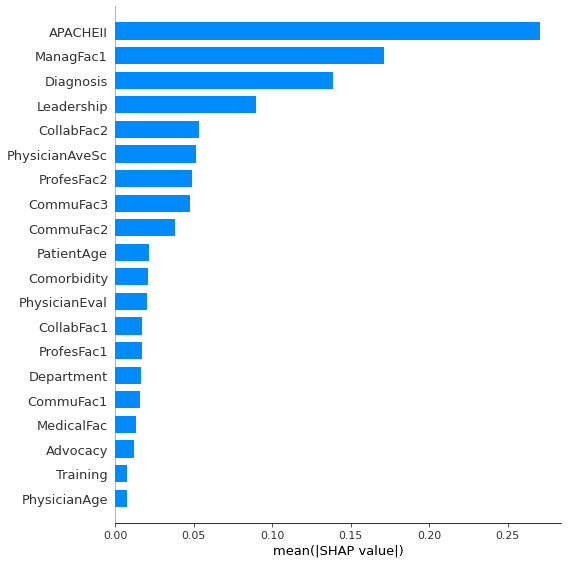

In [ ]:
shap_values = shap.TreeExplainer(model).shap_values(covariates)
shap.summary_plot(
    shap_values, covariates, plot_type="bar", show=False
)
plt.xlabel("mean(|SHAP value|)")
plt.show()

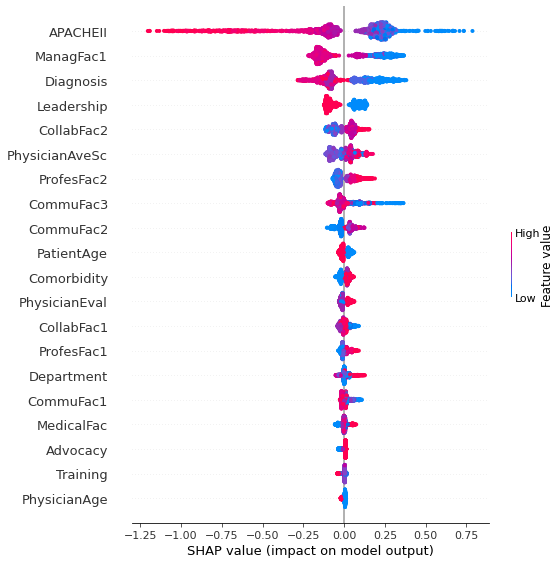

In [ ]:
shap.summary_plot(shap_values, covariates)

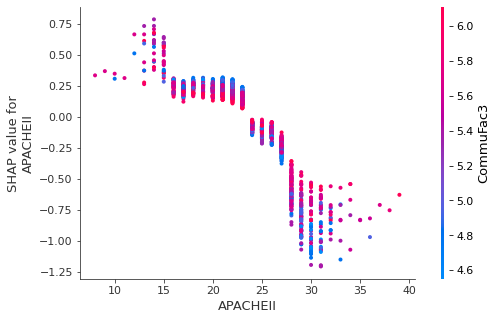

In [ ]:
shap.dependence_plot("APACHEII", shap_values, covariates)

In [ ]:
# takes a couple minutes since SHAP interaction values take a factor of 2 * # features
# more time than SHAP values to compute
shap_interaction_values = shap.TreeExplainer(model).shap_interaction_values(covariates)
shap.summary_plot(shap_interaction_values)

In [ ]:
shap.dependence_plot(
    ("APACHEII", "PatientSex"),
    shap_interaction_values, covariates
)

In [ ]:
tmp = np.abs(shap_interaction_values).sum(0)
for i in range(tmp.shape[0]):
    tmp[i,i] = 0
inds = np.argsort(-tmp.sum(0))[:50]
tmp2 = tmp[inds,:][:,inds]
plt.figure(figsize=(12,12))
plt.imshow(tmp2)
plt.yticks(range(tmp2.shape[0]), covariates.columns[inds], rotation=50.4, horizontalalignment="right")
plt.xticks(range(tmp2.shape[0]), covariates.columns[inds], rotation=50.4, horizontalalignment="left")
plt.gca().xaxis.tick_top()
plt.show()